# SSL Method Comparison

Side-by-side comparison of all 5 self-supervised methods on STL-10:
Autoencoder, SimCLR, BYOL, MAE, I-JEPA.

Metrics: k-NN accuracy, linear probe (full + low-data), training loss, and evaluation trajectories across training.

In [8]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sns.set_theme(style="whitegrid", font_scale=1.1)

METHODS = ["autoencoder", "simclr", "byol", "mae", "ijepa"]
METHOD_LABELS = {"autoencoder": "Autoencoder", "simclr": "SimCLR", "byol": "BYOL", "mae": "MAE", "ijepa": "I-JEPA"}
METHOD_COLORS = {"autoencoder": "#7f8c8d", "simclr": "#e74c3c", "byol": "#3498db", "mae": "#2ecc71", "ijepa": "#9b59b6"}

# Load all eval results
with open(PROJECT_ROOT / "results" / "all_eval_results.json") as f:
    all_results = json.load(f)

# Load training histories
histories = {}
for method in METHODS:
    path = PROJECT_ROOT / "results" / method / "history.json"
    if path.exists():
        with open(path) as f:
            histories[method] = json.load(f)

# Group eval results by method (periodic checkpoints only, sorted by epoch)
eval_by_method = {}
for method in METHODS:
    eval_by_method[method] = sorted(
        [r for r in all_results if r["method"] == method and r["checkpoint_name"].startswith("checkpoint_")],
        key=lambda r: r["epoch"],
    )

print(f"Eval results: {len(all_results)} total")
for m in METHODS:
    print(f"  {METHOD_LABELS[m]:<12s}: {len(eval_by_method[m])} checkpoints, {len(histories.get(m, []))} history entries")

Eval results: 60 total
  Autoencoder : 10 checkpoints, 100 history entries
  SimCLR      : 10 checkpoints, 100 history entries
  BYOL        : 10 checkpoints, 100 history entries
  MAE         : 10 checkpoints, 100 history entries
  I-JEPA      : 10 checkpoints, 100 history entries


## Best Checkpoint Summary

Best checkpoint per method (selected by highest linear probe accuracy).

In [9]:
# Best checkpoint per method (by linear probe)
print(f"{'Method':<14s} {'Epoch':>6s} {'k-NN(20)':>10s} {'Probe':>10s} {'Probe(1%)':>10s} {'Train Loss':>12s}")
print("=" * 66)

best_per_method = {}
for method in METHODS:
    results = eval_by_method[method]
    if not results:
        continue
    best = max(results, key=lambda r: r["linear_probe"])
    best_per_method[method] = best
    print(f"{METHOD_LABELS[method]:<14s} {best['epoch']:>6d} "
          f"{best['knn']['20']*100:>9.2f}% {best['linear_probe']*100:>9.2f}% "
          f"{best['linear_probe_lowdata']*100:>9.2f}% {best['training_loss']:>12.6f}")

Method          Epoch   k-NN(20)      Probe  Probe(1%)   Train Loss
Autoencoder       499     28.24%     46.52%     20.38%     0.005069
SimCLR            399     80.27%     83.29%     67.91%     4.440638
BYOL              449     80.29%     84.12%     68.33%     0.192123
MAE               449     61.00%     80.41%     42.60%     0.124523
I-JEPA             49     48.18%     58.15%     27.74%     0.057453


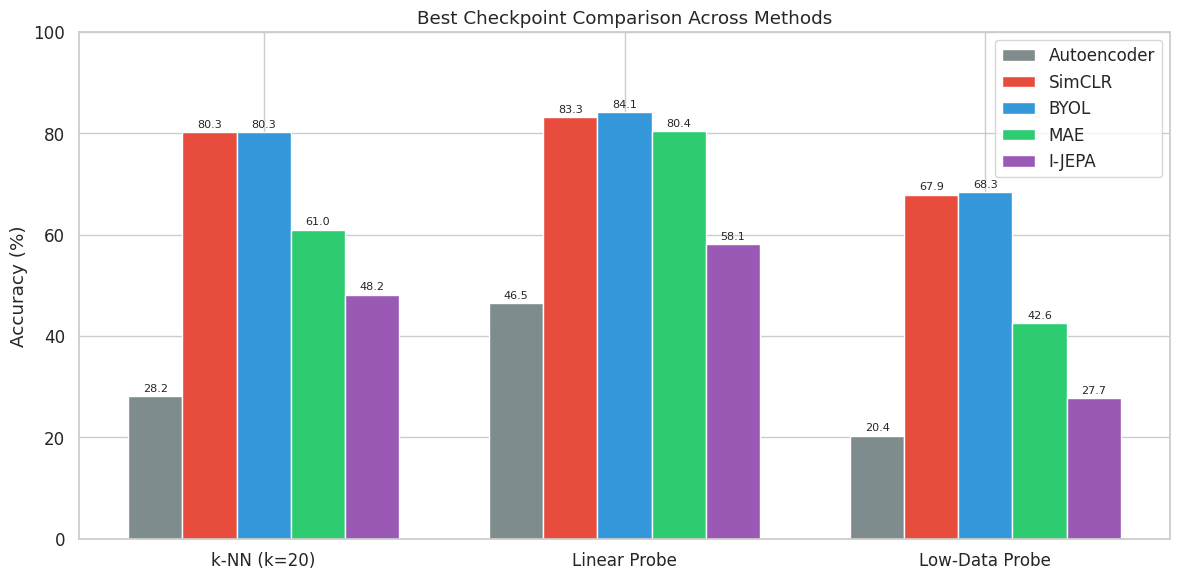

In [10]:
# Bar chart comparison
metrics = ["k-NN (k=20)", "Linear Probe", "Low-Data Probe"]
x = np.arange(len(metrics))
width = 0.15

fig, ax = plt.subplots(figsize=(12, 6))
for i, method in enumerate(METHODS):
    if method not in best_per_method:
        continue
    best = best_per_method[method]
    vals = [best["knn"]["20"] * 100, best["linear_probe"] * 100, best["linear_probe_lowdata"] * 100]
    bars = ax.bar(x + i * width, vals, width, label=METHOD_LABELS[method], color=METHOD_COLORS[method])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Best Checkpoint Comparison Across Methods")
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## k-NN Accuracy vs k (Best Checkpoint)

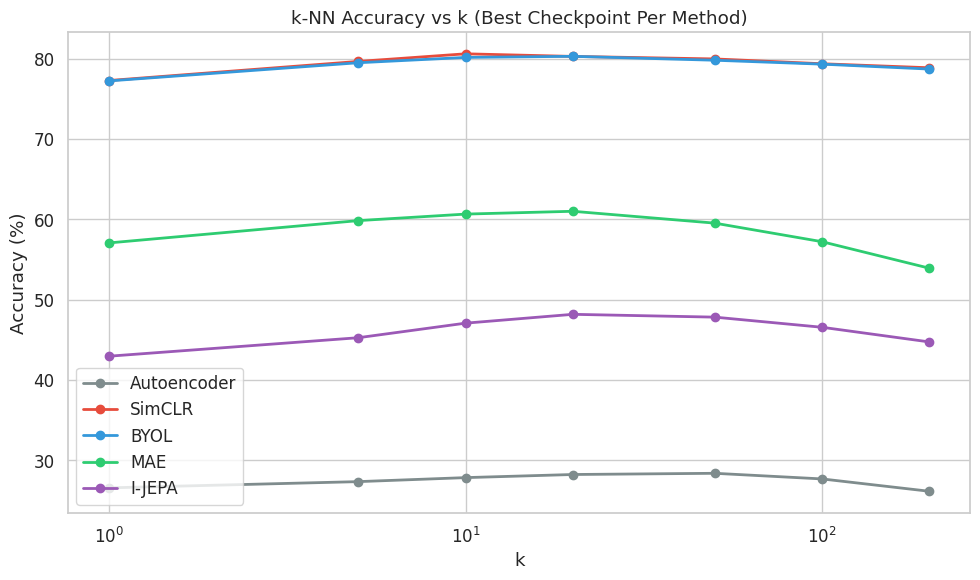

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

for method in METHODS:
    if method not in best_per_method:
        continue
    knn = best_per_method[method]["knn"]
    k_vals = sorted([int(k) for k in knn.keys()])
    accs = [knn[str(k)] * 100 for k in k_vals]
    ax.plot(k_vals, accs, "o-", color=METHOD_COLORS[method], label=METHOD_LABELS[method], linewidth=2)

ax.set_xscale("log")
ax.set_xlabel("k")
ax.set_ylabel("Accuracy (%)")
ax.set_title("k-NN Accuracy vs k (Best Checkpoint Per Method)")
ax.legend()
plt.tight_layout()
plt.show()

## Evaluation Trajectories Across Training

How each metric evolves over training epochs for all methods.

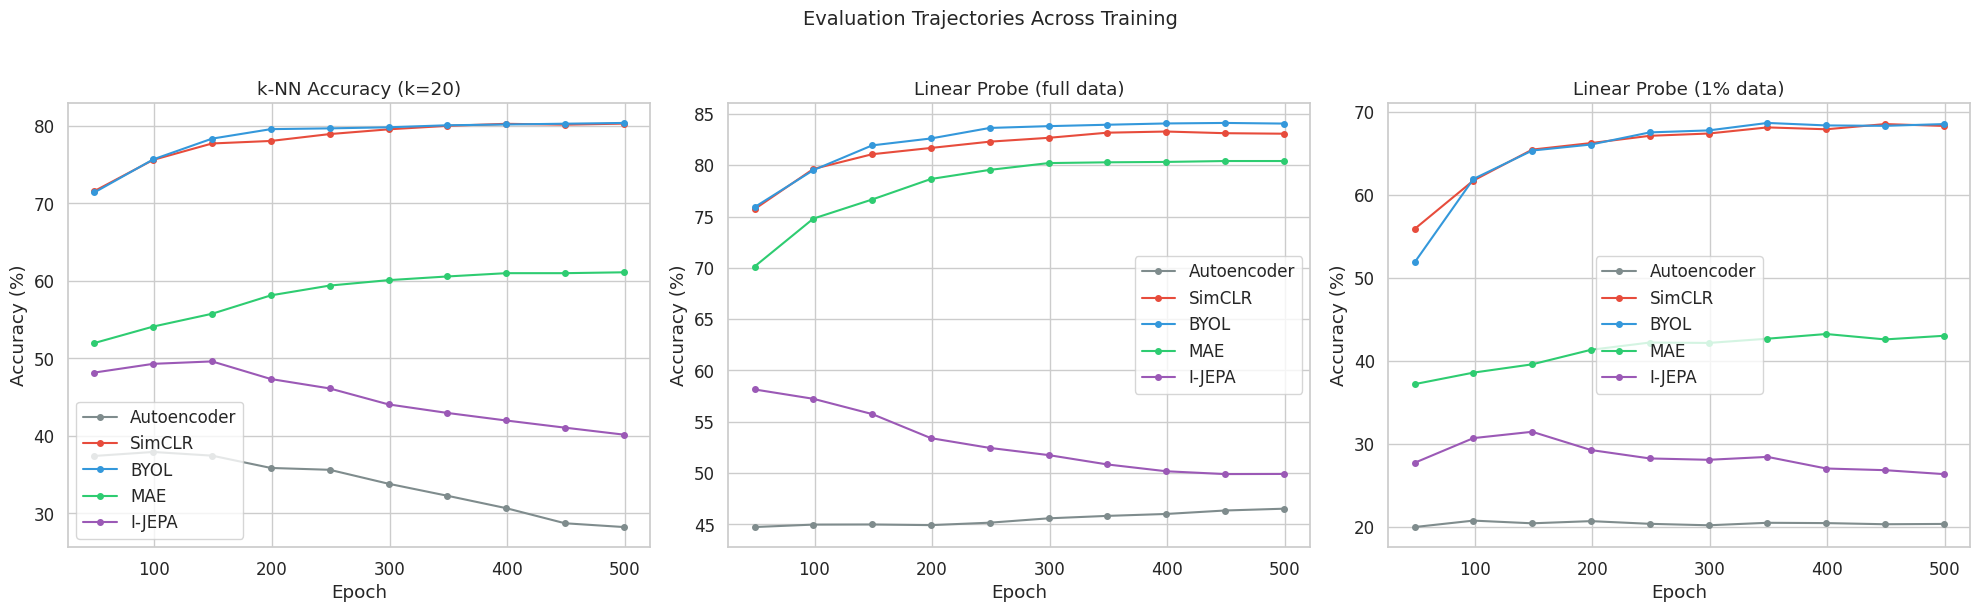

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for method in METHODS:
    results = eval_by_method[method]
    if not results:
        continue
    ep = [r["epoch"] for r in results]
    label = METHOD_LABELS[method]
    color = METHOD_COLORS[method]

    axes[0].plot(ep, [r["knn"]["20"] * 100 for r in results], "o-", color=color, label=label, linewidth=1.5, markersize=4)
    axes[1].plot(ep, [r["linear_probe"] * 100 for r in results], "o-", color=color, label=label, linewidth=1.5, markersize=4)
    axes[2].plot(ep, [r["linear_probe_lowdata"] * 100 for r in results], "o-", color=color, label=label, linewidth=1.5, markersize=4)

axes[0].set_title("k-NN Accuracy (k=20)")
axes[1].set_title("Linear Probe (full data)")
axes[2].set_title("Linear Probe (1% data)")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.legend()

fig.suptitle("Evaluation Trajectories Across Training", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Training Loss Trajectories

Training loss over epochs (from `history.json`). Note: losses are not directly comparable across methods since each uses a different objective.

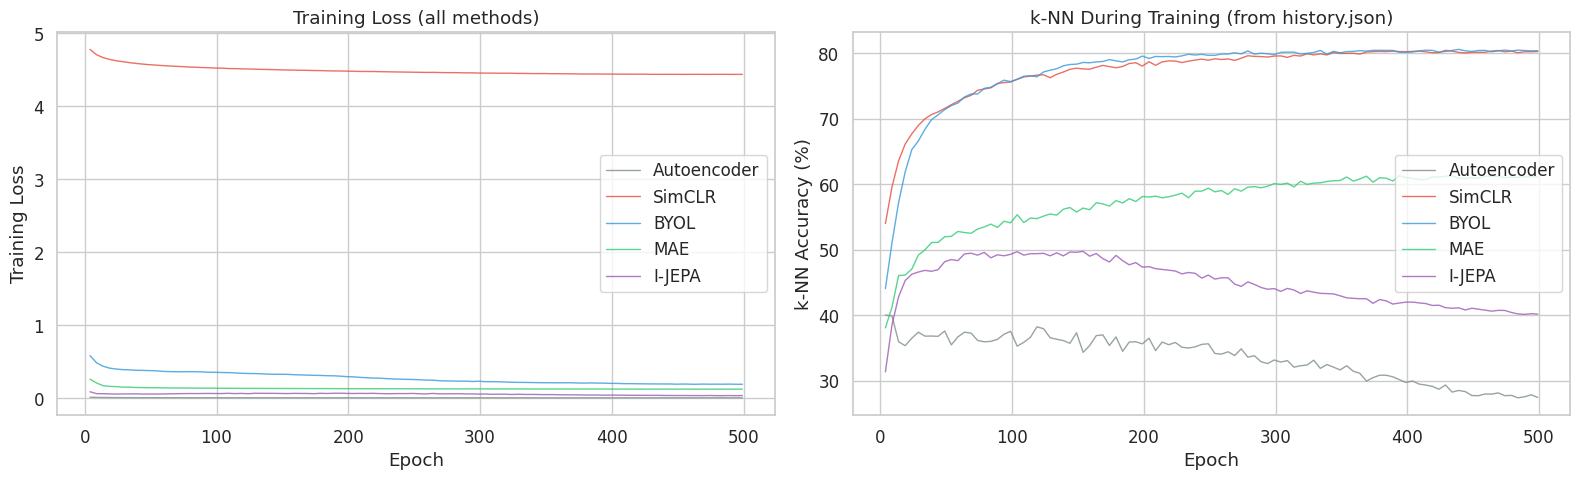

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Training loss (separate y-axes per method since scales differ)
for method in METHODS:
    if method not in histories:
        continue
    h = histories[method]
    ep = [e["epoch"] for e in h]
    loss = [e["loss"] for e in h]
    axes[0].plot(ep, loss, color=METHOD_COLORS[method], label=METHOD_LABELS[method], linewidth=1, alpha=0.8)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss (all methods)")
axes[0].legend()

# k-NN during training (from history.json)
for method in METHODS:
    if method not in histories:
        continue
    h = histories[method]
    ep = [e["epoch"] for e in h]
    knn = [e["knn_top1"] * 100 for e in h]
    axes[1].plot(ep, knn, color=METHOD_COLORS[method], label=METHOD_LABELS[method], linewidth=1, alpha=0.8)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("k-NN Accuracy (%)")
axes[1].set_title("k-NN During Training (from history.json)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Full Results Table

All checkpoints, all methods, sorted by linear probe accuracy.

In [14]:
# Full table sorted by linear probe
periodic = [r for r in all_results if r["checkpoint_name"].startswith("checkpoint_")]
periodic_sorted = sorted(periodic, key=lambda r: r["linear_probe"], reverse=True)

print(f"{'Rank':>4s}  {'Method':<14s} {'Epoch':>6s} {'k-NN(20)':>10s} {'Probe':>10s} {'Probe(1%)':>10s}")
print("=" * 60)
for i, r in enumerate(periodic_sorted, 1):
    print(f"{i:>4d}  {METHOD_LABELS[r['method']]:<14s} {r['epoch']:>6d} "
          f"{r['knn']['20']*100:>9.2f}% {r['linear_probe']*100:>9.2f}% "
          f"{r['linear_probe_lowdata']*100:>9.2f}%")

Rank  Method          Epoch   k-NN(20)      Probe  Probe(1%)
   1  BYOL              449     80.29%     84.12%     68.33%
   2  BYOL              399     80.19%     84.08%     68.38%
   3  BYOL              499     80.39%     84.06%     68.54%
   4  BYOL              349     80.09%     83.95%     68.67%
   5  BYOL              299     79.83%     83.81%     67.77%
   6  BYOL              249     79.69%     83.64%     67.54%
   7  SimCLR            399     80.27%     83.29%     67.91%
   8  SimCLR            349     80.01%     83.17%     68.14%
   9  SimCLR            449     80.16%     83.12%     68.54%
  10  SimCLR            499     80.30%     83.08%     68.31%
  11  SimCLR            299     79.56%     82.67%     67.40%
  12  BYOL              199     79.59%     82.61%     66.07%
  13  SimCLR            249     78.95%     82.30%     67.12%
  14  BYOL              149     78.36%     81.94%     65.35%
  15  SimCLR            199     78.06%     81.69%     66.25%
  16  SimCLR            